# VaR, CVaR, and Stress Testing of a Mutual Fund Portfolio

cy2802 Chen Ye

sh4752 Shengsheng He


### 1. Setup

This notebook follows the project requirements by building a historical-simulation framework for portfolio VaR, CVaR, and stress testing.

The key user-defined inputs are `start_date`, `end_date`, `tau`, `d`, `delta`, and `alpha`.  
The calendar dates are matched to the available trading-day price data, and historical horizon returns are constructed for each mutual fund over the investment horizon `tau`.

The rolling step `delta` controls how frequently these horizon returns are sampled. This makes it possible to examine how the estimated VaR and CVaR change under different sampling choices.

The selected `d` mutual funds are combined into an equally weighted portfolio, and the portfolio’s historical return distribution is used for the subsequent VaR, CVaR, and stress-test analysis.


In [52]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", "{:,.6f}".format)


### 2. Parameter Input

`tau` and `delta` are counted in trading days after the calendar has been cleaned. Typical
rolling steps are daily `1`, weekly `5`, monthly `22`, and quarterly `66`.

`alpha` may be entered as a tail probability (`0.05`) or as a confidence level (`0.95`).


In [53]:
# Dates can be any calendar dates within the available data range.
start_date = "2005-12-31"
end_date = "2024-12-31"

# Risk parameters
tau = 252          # investment horizon in trading days
delta = 22        # rolling step in trading days
alpha = 0.05      # tail probability; 0.05 means 95% VaR
d = 20            # number of funds selected from the 50-fund universe

# Portfolio and sampling settings
initial_value = 1_000_000
universe_size = 50
random_seed = 123


### 3. Load Data and Build a Trading Calendar

This section prepares the mutual fund price data used in the historical simulation.

The project data set contains daily adjusted closing prices for both equity mutual funds and bond mutual funds. Although the files are recorded by calendar date, weekends and holidays are included as rows with unchanged prices. Since the VaR and CVaR calculation should be based on trading-day observations, these repeated non-trading rows need to be removed.

To build the trading calendar, the notebook first combines the raw equity and bond price files into one full price matrix. It then compares each row with the previous row. If the full price vector is different from the previous calendar day, the date is treated as a valid trading day and is kept in the sample. If the row is unchanged, it is interpreted as a weekend or holiday observation and is removed.

After this step, the cleaned price matrix contains only trading days. This is important because the investment horizon `tau` and the rolling step `delta` are both interpreted as numbers of trading days in the subsequent return construction.


In [54]:
DATA_DIR = Path("data")

EQUITY_PRICE_FILE = "us_equity_adj_close.csv"
BOND_PRICE_FILE = "us_bond_intermediate_core_adj_close.csv"
EQUITY_SECTOR_FILE = "us_equity_sectors.csv"
BOND_SECTOR_FILE = "us_bond_intermediate_fixed_income_primary_sector.csv"


def load_price_file(file_name: str) -> pd.DataFrame:
    prices = pd.read_csv(DATA_DIR / file_name, index_col="as_of", parse_dates=True)
    prices = prices.sort_index()
    prices.index.name = "as_of"
    return prices


raw_equity_prices = load_price_file(EQUITY_PRICE_FILE)
raw_bond_prices = load_price_file(BOND_PRICE_FILE)

combined_raw_prices = pd.concat([raw_equity_prices, raw_bond_prices], axis=1).sort_index()
row_hash = pd.util.hash_pandas_object(combined_raw_prices, index=False)
trading_day_mask = row_hash.ne(row_hash.shift())
trading_calendar = combined_raw_prices.index[trading_day_mask]

equity_prices = raw_equity_prices.loc[trading_calendar]
bond_prices = raw_bond_prices.loc[trading_calendar]
all_prices = pd.concat([equity_prices, bond_prices], axis=1)

print(f"Raw calendar rows: {len(combined_raw_prices):,}")
print(f"Trading-day rows: {len(all_prices):,}")
print(f"Trading date range: {all_prices.index.min().date()} to {all_prices.index.max().date()}")
display(all_prices.head())


Raw calendar rows: 9,133
Trading-day rows: 8,587
Trading date range: 1999-12-31 to 2024-12-31


,B13779,B14678,B09156,B25037,B19389,B19569,B23689,B13231,B23166,B06011,...,B11231,B14035,B01206,B23147,B07393,B12216,B23177,B08486,B26001,B15791
as_of,,,,,,,,,,,,,,,,,,,,,
1999-12-31,20.288500,NaN,18.956700,NaN,"7,827.790000",NaN,17.531100,NaN,NaN,26.751700,...,NaN,NaN,NaN,NaN,11.838200,54.140800,9.958440,33.970600,11.493800,10.023000
2000-01-01,20.288500,NaN,18.956700,NaN,"7,827.790000",NaN,17.531100,NaN,NaN,26.751700,...,NaN,NaN,NaN,NaN,11.838200,54.140800,9.958440,33.970600,11.493800,10.023000
2000-01-03,20.288500,NaN,18.320600,NaN,"7,704.460000",NaN,17.217800,NaN,NaN,26.319300,...,NaN,NaN,NaN,NaN,11.801500,53.968900,9.928050,33.779200,11.445500,10.002800
2000-01-04,20.288500,NaN,17.997400,NaN,"7,418.310000",NaN,16.789700,NaN,NaN,25.562700,...,NaN,NaN,NaN,NaN,11.813700,54.008900,9.958440,33.850800,11.469700,10.023000
2000-01-05,20.288500,NaN,18.091200,NaN,"7,421.600000",NaN,16.862800,NaN,NaN,25.778900,...,NaN,NaN,NaN,NaN,11.764800,53.778100,9.928050,33.725200,11.433500,10.002800


### 3. Core Functions

Below are core functions used.


#### 3.1 map_to_trading_date()

`map_to_trading_date(date_like, calendar: pd.DatetimeIndex, side: str) -> pd.Timestamp` helper function converts a calendar date into a valid trading date from the constructed trading calendar.

If the date is used as `start_date`, the function maps it forward to the next available trading day. If the date is used as `end_date`, the function maps it backward to the previous available trading day.

This ensures that the selected sample period always starts and ends on valid trading days, even if the user enters a weekend or holiday.

In [55]:
def map_to_trading_date(date_like, calendar: pd.DatetimeIndex, side: str) -> pd.Timestamp:
    """Map a calendar date to a trading date.

    side='start' maps forward to the next available trading day.
    side='end' maps backward to the previous available trading day.
    """
    date = pd.Timestamp(date_like).normalize()
    if side == "start":
        pos = calendar.searchsorted(date, side="left")
        if pos >= len(calendar):
            raise ValueError(f"start_date {date.date()} is after the last available trading date.")
        return calendar[pos]
    if side == "end":
        pos = calendar.searchsorted(date, side="right") - 1
        if pos < 0:
            raise ValueError(f"end_date {date.date()} is before the first available trading date.")
        return calendar[pos]
    raise ValueError("side must be 'start' or 'end'.")

#### 3.2 resolve_alpha()

`resolve_alpha(alpha_value: float) -> tuple[float, float]` helper function standardizes the user input for `alpha`.

If the user enters a small value such as `0.05`, it is treated as the tail probability. If the user enters a large value such as `0.95`, it is treated as the confidence level.

The function returns both values so that the VaR and CVaR calculations can use the tail probability, while the output can still report the corresponding confidence level.

In [56]:
def resolve_alpha(alpha_value: float) -> tuple[float, float]:
    # Return (tail_probability, confidence_level).
    if not 0 < alpha_value < 1:
        raise ValueError("alpha must be between 0 and 1.")
    if alpha_value <= 0.5:
        tail_probability = alpha_value
        confidence_level = 1 - alpha_value
    else:
        confidence_level = alpha_value
        tail_probability = 1 - alpha_value
    return tail_probability, confidence_level

#### 3.3 validate_inputs()

`validate_inputs(d: int, tau: int, delta: int, universe_size: int) -> None` helper function checks whether the main user-defined parameters are valid before running the risk calculation.

It ensures that `d` is between 1 and the total number of available funds, and that both `tau` and `delta` are positive integers measured in trading days.

This helps catch invalid inputs early and avoids errors later in the return construction and portfolio simulation.

In [57]:
def validate_inputs(d: int, tau: int, delta: int, universe_size: int) -> None:
    if not 1 <= d <= universe_size:
        raise ValueError(f"d must satisfy 1 <= d <= {universe_size}.")
    if tau < 1:
        raise ValueError("tau must be a positive integer number of trading days.")
    if delta < 1:
        raise ValueError("delta must be a positive integer number of trading days.")

#### 3.4 window_positions()

`window_positions(prices: pd.DataFrame, start_date, end_date, tau: int, delta: int)` helper function determines the start and end positions used to calculate historical horizon returns.

It first maps the user-provided `start_date` and `end_date` to valid trading dates. Then, using the investment horizon `tau` and rolling step `delta`, it creates a sequence of rolling windows within the selected sample period.

Each window starts at one trading-day position and ends `tau` trading days later. If the selected date range is too short to contain at least one valid horizon return, the function raises an error.


In [58]:

def window_positions(prices: pd.DataFrame, start_date, end_date, tau: int, delta: int):
    calendar = prices.index
    mapped_start = map_to_trading_date(start_date, calendar, "start")
    mapped_end = map_to_trading_date(end_date, calendar, "end")
    start_pos = calendar.get_loc(mapped_start)
    end_pos = calendar.get_loc(mapped_end)
    n_obs = end_pos - start_pos + 1
    L = (n_obs - tau - 1) // delta + 1
    if L < 1:
        raise ValueError(
            "The selected date window is too short. "
            f"Need at least tau+1={tau + 1} trading-day prices; got {n_obs}."
        )
    start_positions = start_pos + np.arange(L) * delta
    end_positions = start_positions + tau
    return mapped_start, mapped_end, start_positions, end_positions

#### 3.5 eligible_symbols()

`eligible_symbols(prices: pd.DataFrame, start_positions: np.ndarray, end_positions: np.ndarray) -> list[str]` helper function checks which mutual funds can be used in the selected return windows.

For each fund, it looks at all prices needed to calculate the rolling horizon returns. A fund is considered eligible only if all required prices are available and strictly positive.

This prevents missing values or invalid prices from affecting the portfolio return, VaR, and CVaR calculations.

In [59]:
def eligible_symbols(prices: pd.DataFrame, start_positions: np.ndarray, end_positions: np.ndarray) -> list[str]:
    needed_positions = np.unique(np.r_[start_positions, end_positions])
    needed_prices = prices.iloc[needed_positions]
    valid = needed_prices.notna().all(axis=0)
    positive = (needed_prices > 0).all(axis=0)
    return prices.columns[valid & positive].tolist()

#### 3.6 choose_universe_and_portfolio()

`choose_universe_and_portfolio(prices: pd.DataFrame, start_positions: np.ndarray, end_positions: np.ndarray, d: int, universe_size: int = 50, random_seed: int | None = None) `helper function selects the mutual funds used in the simulation.

It first identifies the funds with complete and valid price data in the selected date window. From these eligible funds, it randomly selects a fund universe, and then randomly chooses `d` funds to form the equally weighted portfolio.

If fewer than 50 funds have complete data, the function uses the available eligible funds and prints a warning. If `d` is larger than the number of eligible funds, the function raises an error.

In [60]:
def choose_universe_and_portfolio(
    prices: pd.DataFrame,
    start_positions: np.ndarray,
    end_positions: np.ndarray,
    d: int,
    universe_size: int = 50,
    random_seed: int | None = None
):
    symbols = eligible_symbols(prices, start_positions, end_positions)
    actual_universe_size = min(universe_size, len(symbols))
    if len(symbols) < universe_size:
        print(
            f"Warning: only {len(symbols)} funds have complete data in this window; "
            f"using a {actual_universe_size}-fund universe instead of {universe_size}."
        )
    if d > actual_universe_size:
        raise ValueError(
            f"d={d} is larger than the {actual_universe_size} funds with complete data "
            "in the selected date window. Shorten the window, reduce tau, or reduce d."
        )
    rng = np.random.default_rng(random_seed)
    universe = rng.choice(symbols, size=actual_universe_size, replace=False).tolist()
    portfolio = rng.choice(universe, size=d, replace=False).tolist()
    return universe, portfolio

#### 3.7 historical_return_distribution()
`
historical_return_distribution(prices: pd.DataFrame, symbols: list[str], start_positions: np.ndarray, end_positions: np.ndarray) -> pd.DataFrame` helper function calculates the historical return distribution for the selected funds.

For each rolling window, it compares the fund price at the start position with the price `tau` trading days later.  
The horizon return is calculated as the percentage change from the start price to the end price.

The output is a DataFrame where each row represents one rolling return window, and each column represents one selected mutual fund.  
The function also records the corresponding horizon end date for each return observation.

In [61]:
def historical_return_distribution(
    prices: pd.DataFrame,
    symbols: list[str],
    start_positions: np.ndarray,
    end_positions: np.ndarray,
) -> pd.DataFrame:
    start_prices = prices.iloc[start_positions][symbols].reset_index(drop=True)
    end_prices = prices.iloc[end_positions][symbols].reset_index(drop=True)
    returns = end_prices / start_prices - 1
    returns.index = prices.index[start_positions]
    returns.index.name = "start_date"
    returns["horizon_end_date"] = prices.index[end_positions]
    return returns

#### 3.8 portfolio_distribution()

`portfolio_distribution(fund_returns: pd.DataFrame, symbols: list[str]) -> pd.DataFrame` helper function combines the selected mutual fund returns into an equally weighted portfolio return.

For each rolling window, the portfolio return is calculated as the average return across the selected `d` mutual funds. The function keeps the same start dates and horizon end dates, so each row represents one historical portfolio return over the investment horizon `tau`.

This portfolio return distribution is then used for the VaR and CVaR calculation.

In [62]:
def portfolio_distribution(fund_returns: pd.DataFrame, symbols: list[str]) -> pd.DataFrame:
    out = pd.DataFrame(index=fund_returns.index)
    out["horizon_end_date"] = fund_returns["horizon_end_date"].values
    out["portfolio_return"] = fund_returns[symbols].mean(axis=1)
    return out

#### 3.9 var_cvar_from_returns()

`var_cvar_from_returns(portfolio_returns: pd.Series, alpha: float, initial_value: float = 1_000_000) -> dict` helper function converts historical portfolio returns into dollar losses based on the initial portfolio value.

VaR is calculated as the loss quantile at the selected confidence level. CVaR is calculated as the average loss among the scenarios that are worse than or equal to the VaR threshold.

The function also reports summary information such as the mean loss, maximum loss, tail probability, confidence level, and the number of historical scenarios used in the calculation.

And below is the detailed method to calculate VaR and CVaR.

For each scenario, the portfolio loss is defined as:

$$
L_j = -V_0 R_j
$$

where $V_0$ is the initial portfolio value and $R_j$ is the portfolio return in scenario $j$.

VaR is the empirical loss quantile at the confidence level $\alpha$:

$$
\text{VaR}_{\alpha} = q_{\alpha}(L)
$$

CVaR is the average loss among scenarios worse than or equal to VaR:

$$
\text{CVaR}_{\alpha}
=
\frac{1}{N_{\text{tail}}}
\sum_{j: L_j \geq \text{VaR}_{\alpha}} L_j
$$

In [63]:
def var_cvar_from_returns(
    portfolio_returns: pd.Series,
    alpha: float,
    initial_value: float = 1_000_000
) -> dict:
    tail_probability, confidence_level = resolve_alpha(alpha)
    losses = -initial_value * portfolio_returns.astype(float)
    var = losses.quantile(confidence_level, interpolation="higher")
    tail_losses = losses[losses >= var]
    cvar = tail_losses.mean()
    return {
        "tail_probability": tail_probability,
        "confidence_level": confidence_level,
        "VaR": var,
        "CVaR": cvar,
        "mean_loss": losses.mean(),
        "max_loss": losses.max(),
        "num_scenarios": len(losses),
    }

### 4. VaR and CVaR

#### 4.1 VaR and CVaR Calculation

This section runs the full historical simulation workflow using the user-defined inputs.

First, the inputs are validated to make sure that `d`, `tau`, and `delta` are valid. The selected calendar start and end dates are then mapped to available trading dates, and rolling return windows are created based on the investment horizon `tau` and rolling step `delta`.

Next, the notebook randomly selects an eligible universe of mutual funds and chooses `d` funds to form the equally weighted portfolio. Historical horizon returns are calculated for the selected funds, and the portfolio return distribution is obtained by averaging the selected fund returns in each scenario.

Finally, the portfolio return distribution is converted into dollar losses based on the initial investment value, and VaR and CVaR are calculated at the selected confidence level.

In [64]:
validate_inputs(d=d, tau=tau, delta=delta, universe_size=universe_size)

mapped_start, mapped_end, start_positions, end_positions = window_positions(
    all_prices, start_date, end_date, tau, delta
)
universe_symbols, portfolio_symbols = choose_universe_and_portfolio(
    all_prices,
    start_positions,
    end_positions,
    d=d,
    universe_size=universe_size,
    random_seed=random_seed,
)

fund_return_distribution = historical_return_distribution(
    all_prices, portfolio_symbols, start_positions, end_positions
)
portfolio_return_distribution = portfolio_distribution(fund_return_distribution, portfolio_symbols)
risk_result = var_cvar_from_returns(
    portfolio_return_distribution["portfolio_return"],
    alpha=alpha,
    initial_value=initial_value,
)

print(f"Input start_date={start_date} mapped to trading date {mapped_start.date()}")
print(f"Input end_date={end_date} mapped to trading date {mapped_end.date()}")
print(f"tau={tau}, delta={delta}, scenarios={risk_result['num_scenarios']}")
print(f"alpha input={alpha}; confidence level used={risk_result['confidence_level']:.2%}")
print(f"Selected portfolio symbols ({len(portfolio_symbols)}): {portfolio_symbols}")

risk_table = pd.Series(risk_result, name="value").to_frame()
display(risk_table)
display(portfolio_return_distribution.head())


Input start_date=2005-12-31 mapped to trading date 2005-12-31
Input end_date=2024-12-31 mapped to trading date 2024-12-31
tau=252, delta=22, scenarios=303
alpha input=0.05; confidence level used=95.00%
Selected portfolio symbols (20): ['B13779', 'B06905', 'B13582', 'B15791', 'B08417', 'B09934', 'B12375', 'B00725', 'B02032', 'B02943', 'B12216', 'B01206', 'B01060', 'B12752', 'B05847', 'B05924', 'B03459', 'B01061', 'B03784', 'B11079']


,value
tail_probability,0.050000
confidence_level,0.950000
VaR,"131,205.635966"
CVaR,"189,486.185821"
mean_loss,"-56,403.226581"
max_loss,"268,710.707985"
num_scenarios,303.000000


,horizon_end_date,portfolio_return
start_date,,
2005-12-31,2006-09-09,0.030700
2006-01-22,2006-10-01,0.034045
2006-02-13,2006-10-23,0.057844
2006-03-07,2006-11-14,0.069350
2006-03-29,2006-12-06,0.064632




Below coddes visualize the simulated portfolio loss distribution.

The portfolio returns are first converted into dollar losses using the initial investment value. A histogram is then used to show the frequency of different loss outcomes.

The vertical dashed lines mark the estimated VaR and CVaR levels, making it easier to see where the tail-risk thresholds are located in the loss distribution.

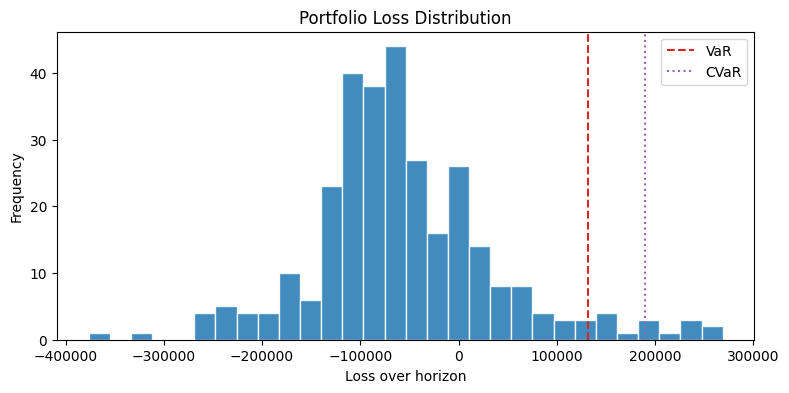

In [65]:
losses = -initial_value * portfolio_return_distribution["portfolio_return"]
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(losses, bins=30, edgecolor="white", alpha=0.85)
ax.axvline(risk_result["VaR"], color="tab:red", linestyle="--", label="VaR")
ax.axvline(risk_result["CVaR"], color="tab:purple", linestyle=":", label="CVaR")
ax.set_title("Portfolio Loss Distribution")
ax.set_xlabel("Loss over horizon")
ax.set_ylabel("Frequency")
ax.legend()
plt.show()


#### 4.2 Does it matter whether returns are annualized or not?

In this project, returns are not annualized when computing VaR and CVaR. Since VaR and CVaR are calculated for the selected investment horizon `tau`, the losses should be based on the actual `tau`-horizon returns. Annualizing the returns would change the scale of the loss distribution and would no longer represent the dollar risk over the chosen horizon.

#### 4.3 Portfolio Size and Diversification Effect

This section examines how the number of mutual funds in the portfolio affects VaR and CVaR.

For each portfolio size `d`, the notebook randomly selects `d` funds from the eligible universe and calculates the corresponding portfolio VaR and CVaR. To reduce the effect of one random portfolio selection, this process is repeated multiple times for each value of `d`.

The final summary table reports the average VaR and CVaR, as well as their standard deviations across repeated simulations.  
The line chart then shows how the average risk measures change as the portfolio includes more mutual funds.

This helps evaluate whether increasing the number of funds provides diversification benefits and reduces downside portfolio risk.

In [66]:
d_values = [5, 10, 20, 30, 40, 50]
n_repeats = 100

records = []

for d_test in d_values:
    if d_test > len(universe_symbols):
        continue

    for repeat in range(n_repeats):
        rng = np.random.default_rng(random_seed + repeat)

        test_portfolio_symbols = rng.choice(
            universe_symbols,
            size=d_test,
            replace=False
        ).tolist()

        test_fund_returns = historical_return_distribution(
            all_prices,
            test_portfolio_symbols,
            start_positions,
            end_positions
        )

        test_portfolio_distribution = portfolio_distribution(
            test_fund_returns,
            test_portfolio_symbols
        )

        test_risk_result = var_cvar_from_returns(
            test_portfolio_distribution["portfolio_return"],
            alpha=alpha,
            initial_value=initial_value
        )

        records.append(
            {
                "d": d_test,
                "repeat": repeat,
                "VaR": test_risk_result["VaR"],
                "CVaR": test_risk_result["CVaR"],
                "mean_loss": test_risk_result["mean_loss"],
                "max_loss": test_risk_result["max_loss"],
                "num_scenarios": test_risk_result["num_scenarios"],
            }
        )

d_repeat_results = pd.DataFrame(records)

d_summary = (
    d_repeat_results
    .groupby("d")
    .agg(
        VaR_mean=("VaR", "mean"),
        VaR_std=("VaR", "std"),
        CVaR_mean=("CVaR", "mean"),
        CVaR_std=("CVaR", "std"),
        mean_loss_mean=("mean_loss", "mean"),
        max_loss_mean=("max_loss", "mean"),
        num_scenarios=("num_scenarios", "first"),
    )
)

display(d_summary)

,VaR_mean,VaR_std,CVaR_mean,CVaR_std,mean_loss_mean,max_loss_mean,num_scenarios
d,,,,,,,
5,"126,474.195637","32,862.269857","194,706.881017","55,502.117904","-57,280.494587","275,930.166509",303
10,"121,713.330837","20,008.869284","177,084.145589","35,206.526368","-53,161.259214","245,241.274995",303
20,"123,717.952058","11,761.512549","182,844.550615","19,936.195212","-54,894.520198","255,510.106345",303
30,"122,707.432121","7,254.722738","182,529.129174","12,255.146657","-55,043.037463","255,151.163472",303
40,"121,836.978581","4,702.246946","181,575.673387","5,117.275187","-54,737.316644","253,907.736623",303


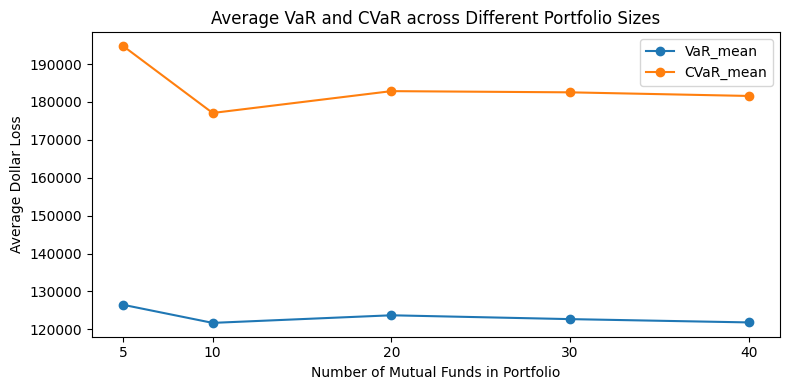

In [67]:
ax = d_summary[["VaR_mean", "CVaR_mean"]].plot(
    kind="line",
    marker="o",
    figsize=(8, 4)
)

ax.set_title("Average VaR and CVaR across Different Portfolio Sizes")
ax.set_xlabel("Number of Mutual Funds in Portfolio")
ax.set_ylabel("Average Dollar Loss")

plt.xticks(d_summary.index)
plt.tight_layout()
plt.show()

The portfolio-size comparison shows some diversification effect, but the pattern is not perfectly monotonic.

When the number of mutual funds increases from `5` to `10`, both average VaR and average CVaR decrease noticeably. This suggests that adding more funds can reduce downside risk through diversification, especially when the portfolio is initially small.

However, after `d = 10`, the risk measures become relatively stable. VaR stays around the same level, and CVaR slightly increases for `d = 20` and `d = 30` before decreasing slightly again at `d = 40`. This means that simply adding more funds does not always lead to a large additional reduction in tail risk.

One possible reason is that many mutual funds may share similar market or sector exposures, so the marginal diversification benefit becomes limited after the portfolio already contains enough funds. Overall, the result suggests that diversification helps reduce risk at first, but the benefit becomes weaker as the portfolio size increases.

### 5. Stress Test

The guidance says sector stress tests would be applied to underlying holdings. These files do
not include security-level holdings, so this notebook uses the available fund-level sector
exposures as a proxy. A shock of `-0.10` to a sector changes each fund's horizon return by:

$$
\text{fund return} + \text{sector exposure weight} \times \text{shock}.
$$

For equity funds, sectors come from `us_equity_sectors.csv`; for bond funds, primary sectors come from `us_bond_intermediate_fixed_income_primary_sector.csv`.

Below are the functions used in stress test.


#### 5.1 load_latest_sector_exposure()

`load_latest_sector_exposure(file_name: str, selected_symbols: list[str], as_of_date) -> pd.DataFrame` helper function loads the most recent sector exposure data for the selected mutual funds.

For each fund, it keeps the latest available sector exposure observation on or before the selected `as_of_date`. The exposure values are converted from percentages to decimals, so they can be used directly in the stress-test calculation.

If a selected fund does not have available sector exposure data, its missing exposure values are filled with zero.

In [68]:
def load_latest_sector_exposure(file_name: str, selected_symbols: list[str], as_of_date) -> pd.DataFrame:
    sectors = pd.read_csv(DATA_DIR / file_name)
    sectors["as_of"] = pd.to_datetime(sectors["as_of"])
    as_of_month = pd.Timestamp(as_of_date).to_period("M").to_timestamp()
    sectors = sectors[(sectors["ask_id"].isin(selected_symbols)) & (sectors["as_of"] <= as_of_month)]
    if sectors.empty:
        return pd.DataFrame(index=selected_symbols)

    sectors = sectors.sort_values(["ask_id", "as_of"]).groupby("ask_id").tail(1)
    exposure_cols = [c for c in sectors.columns if c not in {"as_of", "ask_id"}]
    out = sectors.set_index("ask_id")[exposure_cols].astype(float) / 100.0
    return out.reindex(selected_symbols).fillna(0.0)

#### 5.2 portfolio_sector_exposure()

`portfolio_sector_exposure(selected_symbols: list[str], as_of_date) -> pd.Series` helper function summarizes the sector exposure of the selected portfolio.

It separates the selected funds into equity funds and bond funds, then loads the latest available sector exposure data for each group. After combining the exposure data, it calculates the portfolio-level sector exposure by taking the average exposure across the selected funds.

The result is sorted from the largest sector exposure to the smallest, which helps identify the main sectors driving the portfolio’s stress-test

In [69]:
def portfolio_sector_exposure(selected_symbols: list[str], as_of_date) -> pd.Series:
    equity_symbols = [s for s in selected_symbols if s in equity_prices.columns]
    bond_symbols = [s for s in selected_symbols if s in bond_prices.columns]

    pieces = []
    if equity_symbols:
        pieces.append(load_latest_sector_exposure(EQUITY_SECTOR_FILE, equity_symbols, as_of_date))
    if bond_symbols:
        pieces.append(load_latest_sector_exposure(BOND_SECTOR_FILE, bond_symbols, as_of_date))
    if not pieces:
        return pd.Series(dtype=float)

    exposure = pd.concat(pieces, axis=0).fillna(0.0)
    return exposure.mean(axis=0).sort_values(ascending=False)

#### 5.3 stress_test_sector()

`stress_test_sector(fund_returns: pd.DataFrame, selected_symbols: list[str], sector_name: str, shock: float, alpha: float, initial_value: float = 1_000_000) -> tuple[pd.DataFrame, dict]` helper function applies a shock to one selected sector and recalculates the portfolio risk.

It first loads the latest available sector exposure for the selected equity and bond funds. Then, for the chosen `sector_name`, each fund’s historical return is adjusted by its sector exposure multiplied by the shock size. The stressed fund returns are averaged to form a new equally weighted portfolio return distribution. 

Finally, VaR and CVaR are recalculated using the stressed portfolio returns, allowing comparison between the original risk and the stressed-scenario risk.


In [70]:
def stress_test_sector(
    fund_returns: pd.DataFrame,
    selected_symbols: list[str],
    sector_name: str,
    shock: float,
    alpha: float,
    initial_value: float = 1_000_000
) -> tuple[pd.DataFrame, dict]:
    equity_symbols = [s for s in selected_symbols if s in equity_prices.columns]
    bond_symbols = [s for s in selected_symbols if s in bond_prices.columns]
    equity_exposure = load_latest_sector_exposure(EQUITY_SECTOR_FILE, equity_symbols, mapped_end)
    bond_exposure = load_latest_sector_exposure(BOND_SECTOR_FILE, bond_symbols, mapped_end)
    exposure = pd.concat([equity_exposure, bond_exposure], axis=0).reindex(selected_symbols).fillna(0.0)

    if sector_name not in exposure.columns:
        valid = exposure.columns.tolist()
        raise ValueError(f"Sector '{sector_name}' not found. Valid sectors include: {valid}")

    stressed_fund_returns = fund_returns[selected_symbols].copy()
    stressed_fund_returns = stressed_fund_returns.add(exposure[sector_name] * shock, axis="columns")

    stressed_portfolio = pd.DataFrame(index=fund_returns.index)
    stressed_portfolio["horizon_end_date"] = fund_returns["horizon_end_date"].values
    stressed_portfolio["portfolio_return"] = stressed_fund_returns.mean(axis=1)
    stressed_risk = var_cvar_from_returns(
        stressed_portfolio["portfolio_return"], alpha=alpha, initial_value=initial_value
    )
    return stressed_portfolio, stressed_risk

Below table shows the top sector exposures of the selected portfolio as of the mapped end date.

In [71]:
sector_exposure = portfolio_sector_exposure(portfolio_symbols, mapped_end)
display(sector_exposure.to_frame("portfolio_weight").head(10))


,portfolio_weight
equity_econ_sector_technology_pct_net,0.116615
fixed_inc_ps_ag_mtge_bck_pct_net,0.075720
equity_econ_sector_financial_services_pct_net,0.068410
equity_econ_sector_consumer_cyclical_pct_net,0.063495
equity_econ_sector_healthcare_pct_net,0.063355
equity_econ_sector_industrials_pct_net,0.051955
equity_econ_sector_communication_services_pct_net,0.040565
fixed_inc_ps_corporate_bond_pct_net,0.035325
equity_econ_sector_consumer_defensive_pct_net,0.030785
fixed_inc_ps_gov_pct_net,0.024300


#### 5.4 Run -10% stress test

This section applies a stress scenario to the portfolio’s largest sector exposure.

The shock is set to `-10%`, meaning that funds with higher exposure to the selected sector receive a larger negative adjustment to their historical returns. After applying the shock, the notebook recalculates the portfolio return distribution and estimates the stressed VaR and CVaR.

The comparison table shows how the main risk measures change from the base case to the stressed scenario, including VaR, CVaR, mean loss, maximum loss, and the number of scenarios.

In [72]:
# stress the portfolio's largest available sector by -10%.
stress_shock = -0.10
stress_sector = sector_exposure.index[0]

stressed_distribution, stressed_risk_result = stress_test_sector(
    fund_return_distribution,
    portfolio_symbols,
    sector_name=stress_sector,
    shock=stress_shock,
    alpha=alpha,
    initial_value=initial_value,
)

comparison = pd.DataFrame(
    {
        "base": risk_result,
        f"stress: {stress_sector} {stress_shock:.0%}": stressed_risk_result,
    }
)
display(comparison.loc[["VaR", "CVaR", "mean_loss", "max_loss", "num_scenarios"]])
display(stressed_distribution.head())


,base,stress: equity_econ_sector_technology_pct_net -10%
VaR,"131,205.635966","142,867.135966"
CVaR,"189,486.185821","201,147.685821"
mean_loss,"-56,403.226581","-44,741.726581"
max_loss,"268,710.707985","280,372.207985"
num_scenarios,303.000000,303.000000


,horizon_end_date,portfolio_return
start_date,,
2005-12-31,2006-09-09,0.019038
2006-01-22,2006-10-01,0.022384
2006-02-13,2006-10-23,0.046183
2006-03-07,2006-11-14,0.057689
2006-03-29,2006-12-06,0.052970


The stress test shows that applying a `-10%` shock to the portfolio’s largest sector exposure increases the portfolio’s downside risk.

In the base case, the VaR is about `$131,206`, while under the stressed scenario it increases to about `$142,867`. Similarly, CVaR rises from about `$189,486` to about `$201,148`. This means that after the sector shock, both the loss threshold and the average tail loss become larger.

The maximum loss also increases from about `$268,711` to about `$280,372`, showing that the worst historical scenario becomes more severe under the stress test. The number of scenarios remains the same at `303`, so the difference comes only from the applied sector shock rather than a change in the sample size.

Overall, the result indicates that the portfolio is meaningfully exposed to the selected sector, and a negative shock to this sector would increase VaR, CVaR, and maximum loss.

#### 5.5 Stress Test Sensitivity Analysis

This section compares how portfolio risk changes under different sector shock sizes.

Instead of using only one fixed stress scenario, the notebook applies several negative shocks to the portfolio’s largest sector exposure.  
For each shock level, VaR and CVaR are recalculated using the stressed portfolio return distribution.

This helps show whether the portfolio’s downside risk increases gradually or sharply as the sector shock becomes more severe.

In [73]:
stress_shocks = [-0.05, -0.10, -0.15, -0.20, -0.25, -0.30]
stress_sector = sector_exposure.index[0]

stress_results = {}

for shock in stress_shocks:
    _, stressed_risk = stress_test_sector(
        fund_return_distribution,
        portfolio_symbols,
        sector_name=stress_sector,
        shock=shock,
        alpha=alpha,
        initial_value=initial_value,
    )

    stress_results[f"{stress_sector} {shock:.0%}"] = stressed_risk

stress_comparison = pd.DataFrame(stress_results)

display(stress_comparison.loc[["VaR", "CVaR", "mean_loss", "max_loss"]])

,equity_econ_sector_technology_pct_net -5%,equity_econ_sector_technology_pct_net -10%,equity_econ_sector_technology_pct_net -15%,equity_econ_sector_technology_pct_net -20%,equity_econ_sector_technology_pct_net -25%,equity_econ_sector_technology_pct_net -30%
VaR,"137,036.385966","142,867.135966","148,697.885966","154,528.635966","160,359.385966","166,190.135966"
CVaR,"195,316.935821","201,147.685821","206,978.435821","212,809.185821","218,639.935821","224,470.685821"
mean_loss,"-50,572.476581","-44,741.726581","-38,910.976581","-33,080.226581","-27,249.476581","-21,418.726581"
max_loss,"274,541.457985","280,372.207985","286,202.957985","292,033.707985","297,864.457985","303,695.207985"


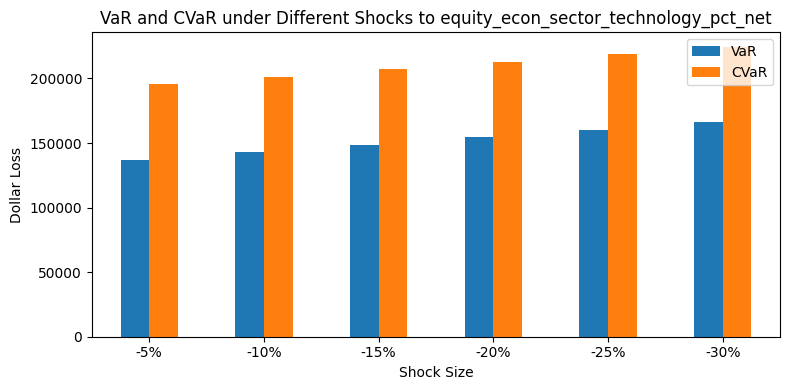

In [74]:
stress_plot = stress_comparison.T[["VaR", "CVaR"]].copy()
stress_plot.index = [f"{shock:.0%}" for shock in stress_shocks]

ax = stress_plot.plot(kind="bar", figsize=(8, 4))

ax.set_title(f"VaR and CVaR under Different Shocks to {stress_sector}")
ax.set_xlabel("Shock Size")
ax.set_ylabel("Dollar Loss")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The bar chart shows a clear increasing pattern in both VaR and CVaR as the sector shock becomes more severe.

When the shock changes from `-5%` to `-30%`, the estimated VaR gradually increases, meaning that the portfolio’s loss threshold becomes larger under stronger negative sector shocks.  
CVaR also rises steadily and remains higher than VaR across all stress scenarios, which indicates that the average tail loss becomes more severe in the worst-case scenarios.

This result suggests that the portfolio has meaningful exposure to the selected technology sector. A larger negative shock to this sector leads to higher downside risk and a larger potential loss.

To make this trend easier to observe, we can also use a line chart to plot VaR and CVaR against the shock size. Compared with the bar chart, a line chart can show the sensitivity pattern more directly and make it easier to see whether the risk measures increase approximately linearly as the shock becomes larger.

In [75]:
# More detailed stress-test sensitivity analysis

stress_shocks = np.arange(-0.05, -0.305, -0.025)
stress_sector = sector_exposure.index[0]

stress_results = {}

for shock in stress_shocks:
    _, stressed_risk = stress_test_sector(
        fund_return_distribution,
        portfolio_symbols,
        sector_name=stress_sector,
        shock=shock,
        alpha=alpha,
        initial_value=initial_value,
    )

    stress_results[shock] = stressed_risk

stress_comparison_dense = pd.DataFrame(stress_results).T
stress_comparison_dense.index.name = "shock"

display(stress_comparison_dense[["VaR", "CVaR", "mean_loss", "max_loss"]])

,VaR,CVaR,mean_loss,max_loss
shock,,,,
-0.050000,"137,036.385966","195,316.935821","-50,572.476581","274,541.457985"
-0.075000,"139,951.760966","198,232.310821","-47,657.101581","277,456.832985"
-0.100000,"142,867.135966","201,147.685821","-44,741.726581","280,372.207985"
-0.125000,"145,782.510966","204,063.060821","-41,826.351581","283,287.582985"
-0.150000,"148,697.885966","206,978.435821","-38,910.976581","286,202.957985"
-0.175000,"151,613.260966","209,893.810821","-35,995.601581","289,118.332985"
-0.200000,"154,528.635966","212,809.185821","-33,080.226581","292,033.707985"
-0.225000,"157,444.010966","215,724.560821","-30,164.851581","294,949.082985"
-0.250000,"160,359.385966","218,639.935821","-27,249.476581","297,864.457985"


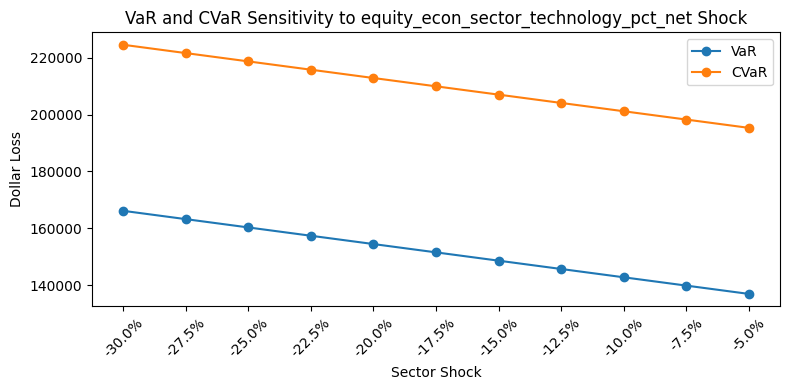

In [76]:
ax = stress_comparison_dense[["VaR", "CVaR"]].plot(
    kind="line",
    marker="o",
    figsize=(8, 4),
)

ax.set_title(f"VaR and CVaR Sensitivity to {stress_sector} Shock")
ax.set_xlabel("Sector Shock")
ax.set_ylabel("Dollar Loss")

ax.set_xticks(stress_comparison_dense.index)
ax.set_xticklabels([f"{x:.1%}" for x in stress_comparison_dense.index], rotation=45)

plt.tight_layout()
plt.show()

The line chart provides a clearer view of the portfolio’s sensitivity to different sector shock sizes.

Although the lines appear to slope downward from left to right, this is because the x-axis is ordered from the most severe shock `-30%` to the mildest shock `-5%`. Interpreted by shock severity, the result shows that both VaR and CVaR increase as the negative sector shock becomes larger.

CVaR remains consistently above VaR across all shock levels, which is expected because CVaR measures the average loss in the tail beyond the VaR threshold. The nearly linear pattern suggests that the portfolio’s downside risk responds steadily to changes in the selected sector shock.

Overall, this sensitivity analysis is meaningful because it shows not only one stressed scenario, but also how portfolio tail risk changes as the shock magnitude increases.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

start_date_widget = widgets.DatePicker(
    description="Start Date",
    value=pd.Timestamp("2005-12-31").date()
)

end_date_widget = widgets.DatePicker(
    description="End Date",
    value=pd.Timestamp("2024-12-31").date()
)

d_widget = widgets.IntSlider(
    value=10,
    min=1,
    max=50,
    step=1,
    description="d"
)

tau_widget = widgets.Dropdown(
    options=[
        ("1 Year", 252),
        ("3 Years", 756),
        ("5 Years", 1260),
        ("Custom: 126 days", 126),
    ],
    value=252,
    description="tau"
)

delta_widget = widgets.Dropdown(
    options=[
        ("Daily", 1),
        ("Weekly", 5),
        ("Monthly", 22),
        ("Quarterly", 66),
    ],
    value=22,
    description="delta"
)

alpha_widget = widgets.FloatSlider(
    value=0.05,
    min=0.01,
    max=0.20,
    step=0.01,
    description="alpha"
)

initial_value_widget = widgets.FloatText(
    value=1_000_000,
    description="Initial $"
)

random_seed_widget = widgets.IntText(
    value=42,
    description="Seed"
)

stress_shock_widget = widgets.FloatSlider(
    value=-0.10,
    min=-0.50,
    max=0.00,
    step=0.01,
    description="Shock"
)

run_button = widgets.Button(
    description="Run Simulation",
    button_style="primary"
)

output = widgets.Output()


def run_ui_simulation(button):
    with output:
        clear_output(wait=True)

        try:
            ui_start_date = pd.Timestamp(start_date_widget.value)
            ui_end_date = pd.Timestamp(end_date_widget.value)
            ui_d = d_widget.value
            ui_tau = tau_widget.value
            ui_delta = delta_widget.value
            ui_alpha = alpha_widget.value
            ui_initial_value = initial_value_widget.value
            ui_random_seed = random_seed_widget.value
            ui_universe_size = 50
            ui_stress_shock = stress_shock_widget.value

            validate_inputs(
                d=ui_d,
                tau=ui_tau,
                delta=ui_delta,
                universe_size=ui_universe_size
            )


            ui_mapped_start, ui_mapped_end, ui_start_positions, ui_end_positions = window_positions(
                all_prices,
                ui_start_date,
                ui_end_date,
                ui_tau,
                ui_delta
            )

            ui_universe_symbols, ui_portfolio_symbols = choose_universe_and_portfolio(
                all_prices,
                ui_start_positions,
                ui_end_positions,
                d=ui_d,
                universe_size=ui_universe_size,
                random_seed=ui_random_seed
            )

            ui_fund_return_distribution = historical_return_distribution(
                all_prices,
                ui_portfolio_symbols,
                ui_start_positions,
                ui_end_positions
            )


            ui_portfolio_return_distribution = portfolio_distribution(
                ui_fund_return_distribution,
                ui_portfolio_symbols
            )


            ui_risk_result = var_cvar_from_returns(
                ui_portfolio_return_distribution["portfolio_return"],
                alpha=ui_alpha,
                initial_value=ui_initial_value
            )


            print("Parameter Summary")
            print("-" * 60)
            print(f"Start date input: {ui_start_date.date()}")
            print(f"Mapped start date: {ui_mapped_start.date()}")
            print(f"End date input: {ui_end_date.date()}")
            print(f"Mapped end date: {ui_mapped_end.date()}")
            print(f"d: {ui_d}")
            print(f"tau: {ui_tau}")
            print(f"delta: {ui_delta}")
            print(f"alpha: {ui_alpha}")
            print(f"initial value: ${ui_initial_value:,.0f}")
            print(f"number of scenarios: {ui_risk_result['num_scenarios']}")
            print()

            print("Selected Portfolio Symbols")
            print("-" * 60)
            print(ui_portfolio_symbols)
            print()


            risk_table = pd.Series(ui_risk_result, name="value").to_frame()
            display(risk_table)


            losses = -ui_initial_value * ui_portfolio_return_distribution["portfolio_return"]

            fig, ax = plt.subplots(figsize=(9, 4))
            ax.hist(losses, bins=30, edgecolor="white", alpha=0.85)
            ax.axvline(ui_risk_result["VaR"], linestyle="--", label="VaR")
            ax.axvline(ui_risk_result["CVaR"], linestyle=":", label="CVaR")
            ax.set_title("Portfolio Loss Distribution")
            ax.set_xlabel("Loss over horizon")
            ax.set_ylabel("Frequency")
            ax.legend()
            plt.show()

            ui_sector_exposure = portfolio_sector_exposure(
                ui_portfolio_symbols,
                ui_mapped_end
            )

            if len(ui_sector_exposure) > 0:
                ui_stress_sector = ui_sector_exposure.index[0]

                ui_stressed_distribution, ui_stressed_risk_result = stress_test_sector(
                    ui_fund_return_distribution,
                    ui_portfolio_symbols,
                    sector_name=ui_stress_sector,
                    shock=ui_stress_shock,
                    alpha=ui_alpha,
                    initial_value=ui_initial_value
                )

                stress_comparison = pd.DataFrame(
                    {
                        "Base": ui_risk_result,
                        f"Stress: {ui_stress_sector} {ui_stress_shock:.0%}": ui_stressed_risk_result,
                    }
                )

                print("Sector Stress Test")
                print("-" * 60)
                print(f"Stress sector: {ui_stress_sector}")
                print(f"Stress shock: {ui_stress_shock:.0%}")
                display(stress_comparison.loc[["VaR", "CVaR", "mean_loss", "max_loss", "num_scenarios"]])

                stressed_losses = -ui_initial_value * ui_stressed_distribution["portfolio_return"]

                fig, ax = plt.subplots(figsize=(9, 4))
                ax.hist(losses, bins=30, alpha=0.60, label="Base Loss")
                ax.hist(stressed_losses, bins=30, alpha=0.60, label="Stressed Loss")
                ax.set_title("Base vs Stressed Loss Distribution")
                ax.set_xlabel("Loss over horizon")
                ax.set_ylabel("Frequency")
                ax.legend()
                plt.show()

            else:
                print("No sector exposure data is available for the selected portfolio.")

        except Exception as e:
            print("Error:")
            print(e)


run_button.on_click(run_ui_simulation)


ui = widgets.VBox([
    widgets.HTML("<h3>VaR, CVaR, and Stress Test Parameter UI</h3>"),
    widgets.HBox([start_date_widget, end_date_widget]),
    widgets.HBox([d_widget, tau_widget, delta_widget]),
    widgets.HBox([alpha_widget, initial_value_widget, random_seed_widget]),
    widgets.HBox([stress_shock_widget, run_button]),
    output
])

display(ui)